In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import resample
from google.colab import files
import warnings
from librosa.sequence import dtw

In [ ]:
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Carregamento dos audios

In [ ]:
print("Faça upload de dois arquivos .mp3 (original e acusado):")
uploaded = files.upload()

file_names = list(uploaded.keys())
if len(file_names) != 2:
    raise ValueError("Você deve carregar exatamente dois arquivos.")

print("\nArquivos enviados:")
for i, name in enumerate(file_names):
    print(f"{i+1}: {name}")

print("\nDigite exatamente o nome do arquivo que corresponde à OBRA ORIGINAL:")
nome_original = input().strip()

if nome_original not in file_names:
    raise ValueError("Nome inválido! Certifique-se de digitar exatamente como aparece acima.")

file_original = nome_original
file_acusado = [f for f in file_names if f != nome_original][0]
print(f"\nEntão o acusado é:\n{file_acusado}")

Faça upload de dois arquivos .mp3 (original e acusado):


Saving Million Years Ago.mp3 to Million Years Ago.mp3
Saving Mulheres.mp3 to Mulheres.mp3

Arquivos enviados:
1: Million Years Ago.mp3
2: Mulheres.mp3

Digite exatamente o nome do arquivo que corresponde à OBRA ORIGINAL:
Mulheres.mp3

Então o acusado é:
Million Years Ago.mp3


In [ ]:
# mesmo sample rate para comparaçao
sr_target = 22050
y_orig, sr_orig = librosa.load(file_original, sr=sr_target, mono=True)
y_acus, sr_acus = librosa.load(file_acusado, sr=sr_target, mono=True)


print(f"\nObra Original: {file_original} (Duração: {librosa.get_duration(y=y_orig, sr=sr_orig):.2f}s)")
print(f"Obra Acusada: {file_acusado} (Duração: {librosa.get_duration(y=y_acus, sr=sr_acus):.2f}s)")


Obra Original: Mulheres.mp3 (Duração: 84.69s)
Obra Acusada: Million Years Ago.mp3 (Duração: 223.71s)


# Extração de Características de Início (Onset Detection Function - ODF)

### A ODF representa a probabilidade de um novo evento sonoro em cada frame

In [ ]:
def plot_onsets_lado_a_lado(y1, sr1, onset_frames1, title1, y2, sr2, onset_frames2, title2, suptitle):
    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=False)
    fig.suptitle(suptitle, fontsize=16)

    librosa.display.waveshow(y1, sr=sr1, ax=axs[0], alpha=0.6)
    if len(onset_frames1) > 0:
        axs[0].vlines(librosa.frames_to_time(onset_frames1, sr=sr1),
                     -1, 1, color='r', alpha=0.9, linestyle='--', label='Onsets')
    axs[0].set_title(title1)
    axs[0].set_ylabel('Amplitude')
    axs[0].legend()
    axs[0].set_xlabel('')

    librosa.display.waveshow(y2, sr=sr2, ax=axs[1], alpha=0.6)
    if len(onset_frames2) > 0:
        axs[1].vlines(librosa.frames_to_time(onset_frames2, sr=sr2),
                     -1, 1, color='r', alpha=0.9, linestyle='--', label='Onsets')
    axs[1].set_title(title2)
    axs[1].set_ylabel('Amplitude')
    axs[1].legend()
    axs[1].set_xlabel('Tempo (segundos)')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

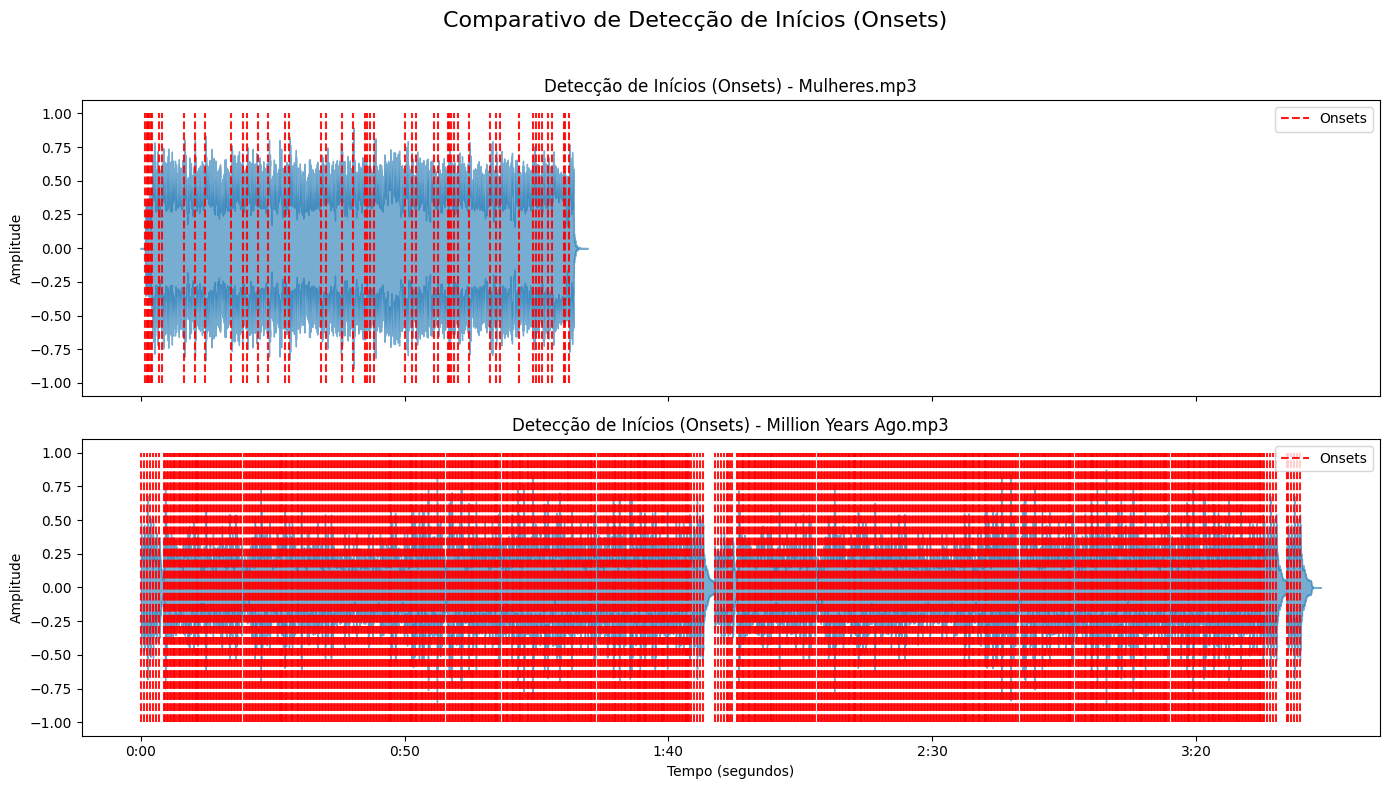

In [ ]:
o_env_orig_strength = librosa.onset.onset_strength(y=y_orig, sr=sr_orig)
o_env_acus_strength = librosa.onset.onset_strength(y=y_acus, sr=sr_acus)

onset_frames_orig = librosa.util.peak_pick(o_env_orig_strength, pre_max=3, post_max=3, pre_avg=3, post_avg=5, delta=0.5, wait=1)
onset_frames_acus = librosa.util.peak_pick(o_env_acus_strength, pre_max=3, post_max=3, pre_avg=3, post_avg=5, delta=0.5, wait=1)

plot_onsets_lado_a_lado(
    y_orig, sr_orig, onset_frames_orig, f'Detecção de Inícios (Onsets) - {file_original}',
    y_acus, sr_acus, onset_frames_acus, f'Detecção de Inícios (Onsets) - {file_acusado}',
    'Comparativo de Detecção de Inícios (Onsets)'
)

In [ ]:
def plot_onset_envelope_lado_a_lado(times1, o_env1, title1,
                                    times2, o_env2, title2,
                                    suptitle='Comparação de Energia de Onset'):
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
    fig.suptitle(suptitle, fontsize=16)

    axs[0].plot(times1, o_env1, color='darkblue')
    axs[0].set_title(title1)
    axs[0].set_xlabel('Tempo (s)')
    axs[0].set_ylabel('Energia de Onset')

    axs[1].plot(times2, o_env2, color='darkred')
    axs[1].set_title(title2)
    axs[1].set_xlabel('Tempo (s)')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


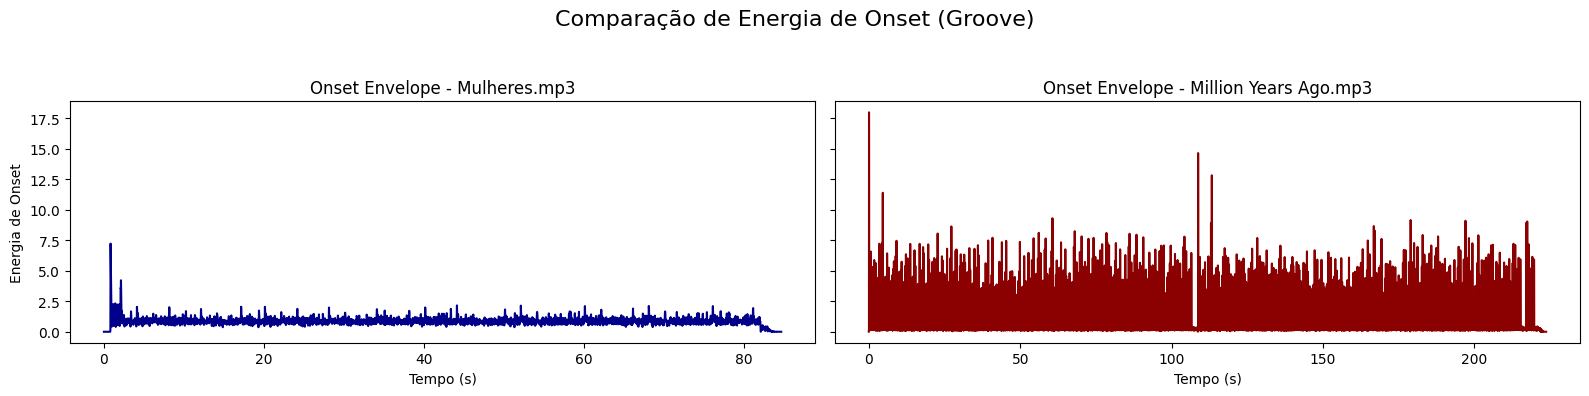

In [ ]:
times_orig = librosa.times_like(o_env_orig_strength, sr=sr_orig)
times_acus = librosa.times_like(o_env_acus_strength, sr=sr_acus)

plot_onset_envelope_lado_a_lado(
    times_orig, o_env_orig_strength, f'Onset Envelope - {file_original}',
    times_acus, o_env_acus_strength, f'Onset Envelope - {file_acusado}',
    suptitle='Comparação de Energia de Onset (Groove)'
)

# Detecção de Batidas (Beat Tracking) e Andamento (Tempo)

### Estima o andamento (BPM) e os timestamps das batidas

In [ ]:
def plot_beats_lado_a_lado(y1, sr1, beats_times1, tempo1, title1, y2, sr2, beats_times2, tempo2, title2, suptitle):
    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=False)
    fig.suptitle(suptitle, fontsize=16)

    librosa.display.waveshow(y1, sr=sr1, ax=axs[0], alpha=0.6)
    axs[0].vlines(beats_times1, -1, 1, color='b', alpha=0.8, linestyle='-', label='Batidas')
    axs[0].set_title(f'{title1} ({tempo1:.2f} BPM)')
    axs[0].set_ylabel('Amplitude')
    axs[0].legend()
    axs[0].set_xlabel('')

    librosa.display.waveshow(y2, sr=sr2, ax=axs[1], alpha=0.6)
    axs[1].vlines(beats_times2, -1, 1, color='b', alpha=0.8, linestyle='-', label='Batidas')
    axs[1].set_title(f'{title2} ({tempo2:.2f} BPM)')
    axs[1].set_ylabel('Amplitude')
    axs[1].legend()
    axs[1].set_xlabel('Tempo (segundos)')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
tempo_orig, beats_orig = librosa.beat.beat_track(y=y_orig, sr=sr_orig)
beats_orig_times = librosa.frames_to_time(beats_orig, sr=sr_orig)

tempo_acus, beats_acus = librosa.beat.beat_track(y=y_acus, sr=sr_acus)
beats_acus_times = librosa.frames_to_time(beats_acus, sr=sr_acus)

tempo_orig_scalar = float(tempo_orig) if isinstance(tempo_orig, np.ndarray) else tempo_orig
tempo_acus_scalar = float(tempo_acus) if isinstance(tempo_acus, np.ndarray) else tempo_acus

print(f"\nAndamento Estimado - {file_original}: {tempo_orig_scalar:.2f} BPM")
print(f"Andamento Estimado - {file_acusado}: {tempo_acus_scalar:.2f} BPM\n")


Andamento Estimado - Mulheres.mp3: 123.05 BPM
Andamento Estimado - Million Years Ago.mp3: 107.67 BPM



/tmp/ipython-input-32-340081062.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tempo_orig_scalar = float(tempo_orig) if isinstance(tempo_orig, np.ndarray) else tempo_orig
/tmp/ipython-input-32-340081062.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tempo_acus_scalar = float(tempo_acus) if isinstance(tempo_acus, np.ndarray) else tempo_acus


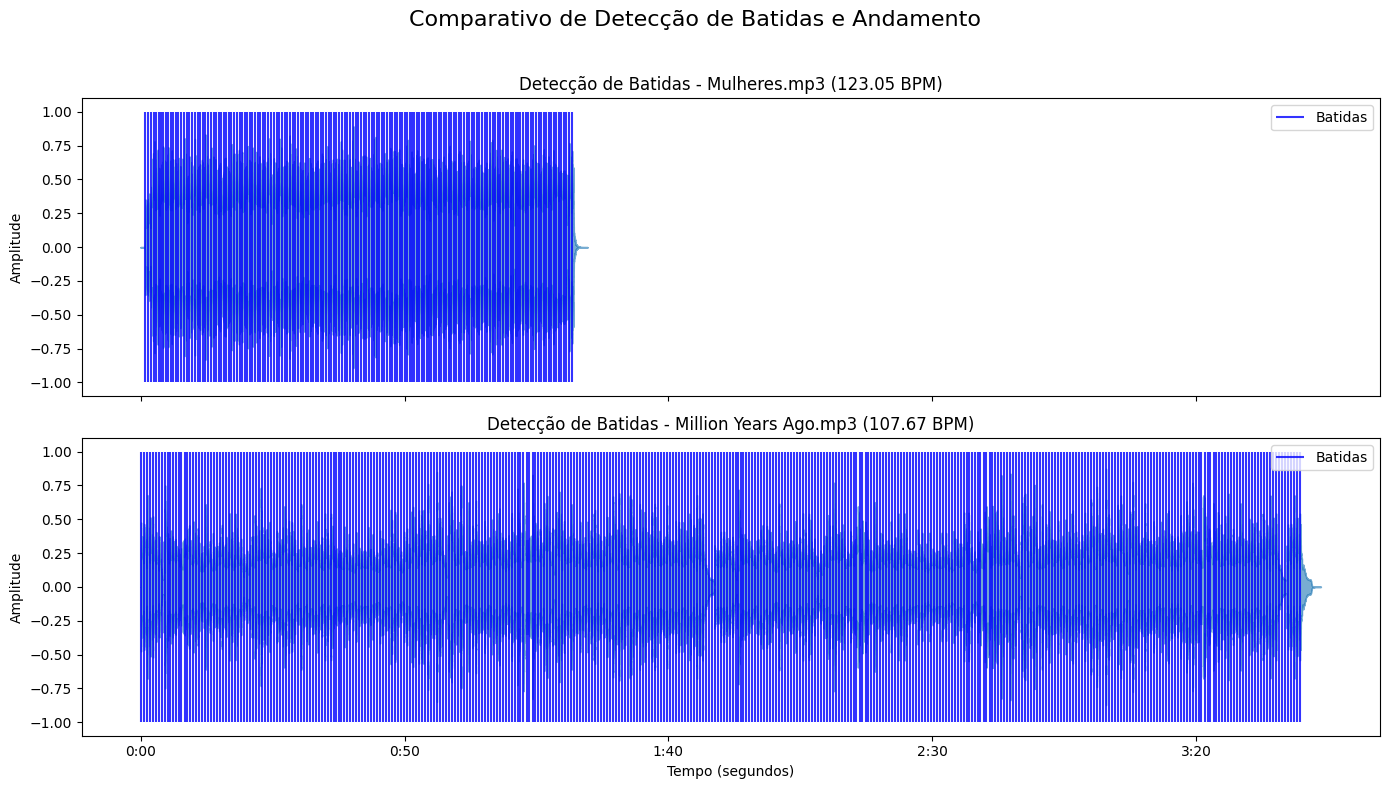

In [ ]:
plot_beats_lado_a_lado(
    y_orig, sr_orig, beats_orig_times, tempo_orig_scalar, f'Detecção de Batidas - {file_original}',
    y_acus, sr_acus, beats_acus_times, tempo_acus_scalar, f'Detecção de Batidas - {file_acusado}',
    'Comparativo de Detecção de Batidas e Andamento'
)

# Análise de Padrões de Pulsação/Ritmo (Tempogramas)
### Tempogramas capturam a variação local de andamento

In [ ]:
def plot_tempograms_lado_a_lado(tempogram1, sr1, hop_length1, tempo_scalar1, title1,
                                tempogram2, sr2, hop_length2, tempo_scalar2, title2, suptitle):
    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)
    fig.suptitle(suptitle, fontsize=16)


    librosa.display.specshow(tempogram1, sr=sr1, hop_length=hop_length1,
                             x_axis='time', y_axis='tempo', cmap='magma_r', ax=axs[0])
    axs[0].axhline(tempo_scalar1, color='w', linestyle='--', alpha=0.8, label=f'BPM Global: {tempo_scalar1:.2f}')
    axs[0].set_title(title1)
    axs[0].set_ylabel('BPM')
    axs[0].legend()
    axs[0].set_xlabel('')

    librosa.display.specshow(tempogram2, sr=sr2, hop_length=hop_length2,
                             x_axis='time', y_axis='tempo', cmap='magma_r', ax=axs[1])
    axs[1].axhline(tempo_scalar2, color='w', linestyle='--', alpha=0.8, label=f'BPM Global: {tempo_scalar2:.2f}')
    axs[1].set_title(title2)
    axs[1].set_ylabel('BPM')
    axs[1].legend()
    axs[1].set_xlabel('Tempo (segundos)')

    plt.colorbar(librosa.display.specshow(tempogram1, cmap='magma_r'), ax=axs[0], label='Atividade de Andamento')
    plt.colorbar(librosa.display.specshow(tempogram2, cmap='magma_r'), ax=axs[1], label='Atividade de Andamento')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


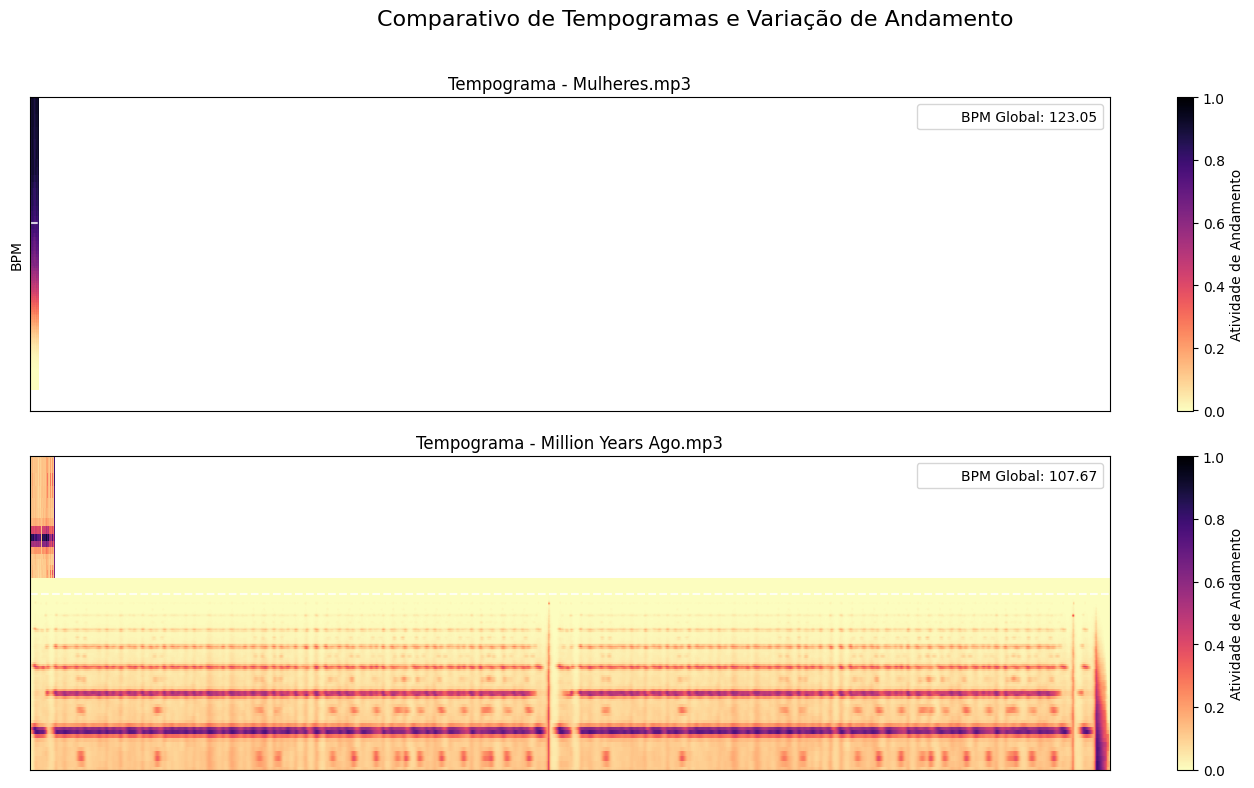

In [ ]:
# muito pesado, esta demorando muito e incorreto
hop_length = 512
win_length_tempo = librosa.time_to_frames(3, sr=sr_target, hop_length=hop_length)

tempogram_orig = librosa.feature.tempogram(y=y_orig, sr=sr_orig, hop_length=hop_length, win_length=win_length_tempo)
tempogram_acus = librosa.feature.tempogram(y=y_acus, sr=sr_acus, hop_length=hop_length, win_length=win_length_tempo)

plot_tempograms_lado_a_lado(
    tempogram_orig, sr_orig, hop_length, tempo_orig_scalar, f'Tempograma - {file_original}',
    tempogram_acus, sr_acus, hop_length, tempo_acus_scalar, f'Tempograma - {file_acusado}',
    'Comparativo de Tempogramas e Variação de Andamento'
)

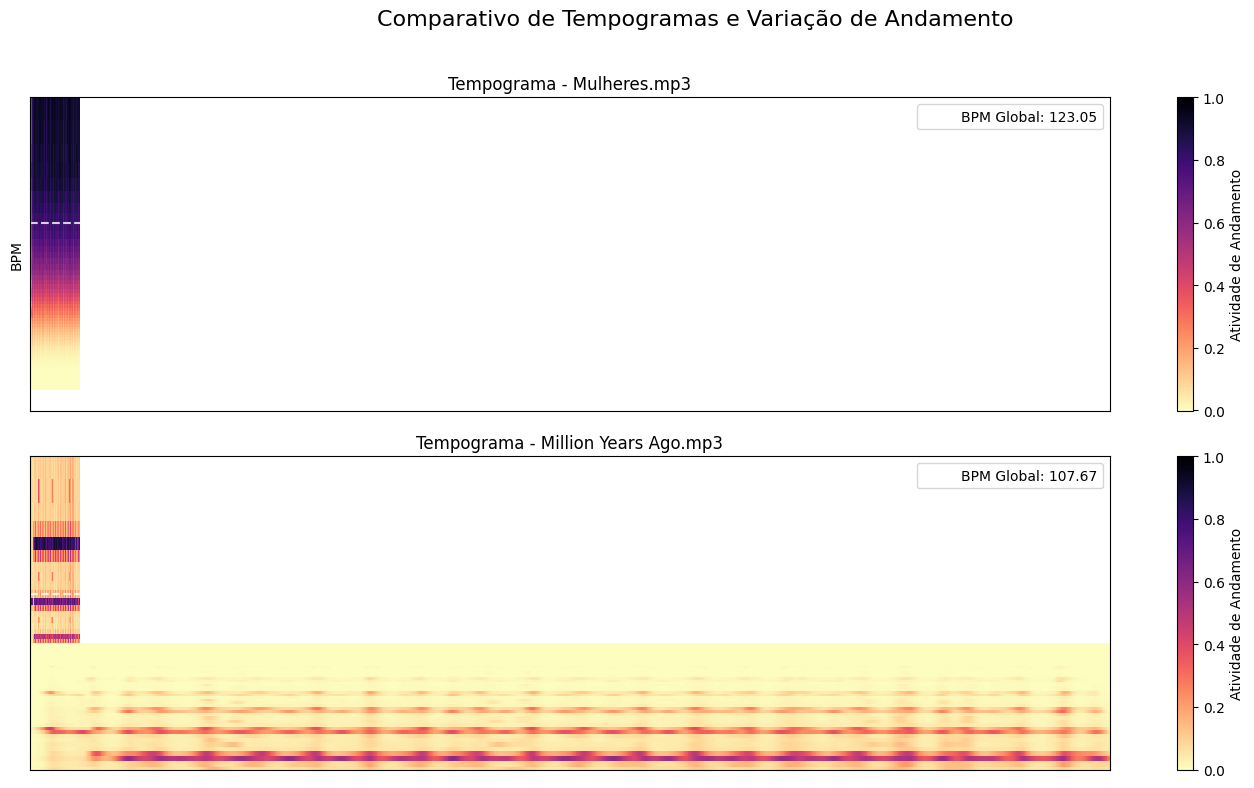

In [ ]:
# Parâmetros mais leves
hop_length = 1024
win_length_tempo = librosa.time_to_frames(3, sr=sr_target, hop_length=hop_length)

#reduzir duração analisada
y_orig = y_orig[:sr_orig * 60]
y_acus = y_acus[:sr_acus * 60]

tempogram_orig = librosa.feature.tempogram(y=y_orig, sr=sr_orig, hop_length=hop_length, win_length=win_length_tempo)
tempogram_acus = librosa.feature.tempogram(y=y_acus, sr=sr_acus, hop_length=hop_length, win_length=win_length_tempo)

plot_tempograms_lado_a_lado(
    tempogram_orig, sr_orig, hop_length, tempo_orig_scalar, f'Tempograma - {file_original}',
    tempogram_acus, sr_acus, hop_length, tempo_acus_scalar, f'Tempograma - {file_acusado}',
    'Comparativo de Tempogramas e Variação de Andamento'
)


# Comparação de Curvas ou Representações do Groove (DTW em Tempogramas)

### Usar DTW para alinhar e comparar a "curva de andamento" ou padrões rítmicos

In [ ]:
def plot_dtw_tempograms_comparativo(D1, wp1, title1, x_label1, y_label1, D2, wp2, title2, x_label2, y_label2, D3, wp3, title3, x_label3, y_label3, suptitle='Comparativo de DTW (Tempogramas - Groove)'):

    fig, axs = plt.subplots(1, 3, figsize=(24, 6), sharex=False, sharey=False)
    fig.suptitle(suptitle, fontsize=18)

    img1 = librosa.display.specshow(D1, cmap='magma_r', ax=axs[0])
    axs[0].plot(wp1[:, 1], wp1[:, 0], color='yellow', linestyle='--', linewidth=2)
    axs[0].set_title(title1)
    axs[0].set_xlabel(x_label1)
    axs[0].set_ylabel(y_label1)
    cbar1 = fig.colorbar(img1, ax=axs[0])
    cbar1.set_label('Custo Acumulado')

    img2 = librosa.display.specshow(D2, cmap='magma_r', ax=axs[1])
    axs[1].plot(wp2[:, 1], wp2[:, 0], color='yellow', linestyle='--', linewidth=2)
    axs[1].set_title(title2)
    axs[1].set_xlabel(x_label2)
    axs[1].set_ylabel(y_label2)
    cbar2 = fig.colorbar(img2, ax=axs[1])
    cbar2.set_label('Custo Acumulado')

    img3 = librosa.display.specshow(D3, cmap='magma_r', ax=axs[2])
    axs[2].plot(wp3[:, 1], wp3[:, 0], color='yellow', linestyle='--', linewidth=2)
    axs[2].set_title(title3)
    axs[2].set_xlabel(x_label3)
    axs[2].set_ylabel(y_label3)
    cbar3 = fig.colorbar(img3, ax=axs[2])
    cbar3.set_label('Custo Acumulado')

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


In [ ]:
tempogram_orig = librosa.feature.tempogram(y=y_orig, sr=sr_target, hop_length=hop_length, win_length=win_length_tempo)
tempogram_acus = librosa.feature.tempogram(y=y_acus, sr=sr_target, hop_length=hop_length, win_length=win_length_tempo)

In [ ]:
# TRANSPOSIÇÃO INCORRETA

'''
min_frames_tempo = min(tempogram_orig.shape[1], tempogram_acus.shape[1])
tempogram_orig_comp = tempogram_orig[:, :min_frames_tempo]
tempogram_acus_comp = tempogram_acus[:, :min_frames_tempo]

tempogram_orig_norm = librosa.util.normalize(tempogram_orig_comp, axis=0)
tempogram_acus_norm = librosa.util.normalize(tempogram_acus_comp, axis=0)


D_tempo_orig, wp_tempo_orig = dtw(X=tempogram_orig_norm.T, Y=tempogram_orig_norm.T, metric='cosine')
D_tempo_acus, wp_tempo_acus = dtw(X=tempogram_acus_norm.T, Y=tempogram_acus_norm.T, metric='cosine')

D_tempo_cross, wp_tempo_cross = dtw(X=tempogram_orig_norm.T, Y=tempogram_acus_norm.T, metric='cosine')

plot_dtw_tempograms_comparativo(
    D_tempo_orig, wp_tempo_orig, f'DTW - {file_original} vs {file_original}', f'Tempo em {file_original}', f'Tempo em {file_original}',
    D_tempo_acus, wp_tempo_acus, f'DTW - {file_acusado} vs {file_acusado}', f'Tempo em {file_acusado}', f'Tempo em {file_acusado}',
    D_tempo_cross, wp_tempo_cross, f'DTW - {file_original} vs {file_acusado}', f'Tempo em {file_acusado}', f'Tempo em {file_original}',
    suptitle='Comparativo DTW de Tempogramas (Groove)'
)

dist_total = D_tempo_cross[wp_tempo_cross[-1, 0], wp_tempo_cross[-1, 1]]
dist_média = dist_total / len(wp_tempo_cross)
print(f'Distância DTW total (tempogramas entre músicas): {dist_total:.4f}')
print(f'Distância DTW média (tempogramas entre músicas): {dist_média:.4f}')
'''


"\nmin_frames_tempo = min(tempogram_orig.shape[1], tempogram_acus.shape[1])\ntempogram_orig_comp = tempogram_orig[:, :min_frames_tempo]\ntempogram_acus_comp = tempogram_acus[:, :min_frames_tempo]\n\ntempogram_orig_norm = librosa.util.normalize(tempogram_orig_comp, axis=0)\ntempogram_acus_norm = librosa.util.normalize(tempogram_acus_comp, axis=0)\n\n\nD_tempo_orig, wp_tempo_orig = dtw(X=tempogram_orig_norm.T, Y=tempogram_orig_norm.T, metric='cosine')\nD_tempo_acus, wp_tempo_acus = dtw(X=tempogram_acus_norm.T, Y=tempogram_acus_norm.T, metric='cosine')\n\nD_tempo_cross, wp_tempo_cross = dtw(X=tempogram_orig_norm.T, Y=tempogram_acus_norm.T, metric='cosine')\n\nplot_dtw_tempograms_comparativo(\n    D_tempo_orig, wp_tempo_orig, f'DTW - {file_original} vs {file_original}', f'Tempo em {file_original}', f'Tempo em {file_original}',\n    D_tempo_acus, wp_tempo_acus, f'DTW - {file_acusado} vs {file_acusado}', f'Tempo em {file_acusado}', f'Tempo em {file_acusado}',\n    D_tempo_cross, wp_tempo_cro

In [ ]:
def plot_dtw_tempograms_comparativo(D1, wp1, title1, x_label1, y_label1,
                                     D2, wp2, title2, x_label2, y_label2,
                                     D3, wp3, title3, x_label3, y_label3, suptitle):
    fig, axs = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)
    fig.suptitle(suptitle, fontsize=16)


    librosa.display.specshow(D1, x_axis='time', y_axis='time', cmap='magma_r', ax=axs[0])
    axs[0].plot(wp1[:, 1], wp1[:, 0], color='yellow', linestyle='--', linewidth=2)
    axs[0].set_title(title1)
    axs[0].set_xlabel(x_label1)
    axs[0].set_ylabel(y_label1)
    fig.colorbar(librosa.display.specshow(D1, cmap='magma_r'), ax=axs[0], label='Custo Acumulado', shrink=0.7)

    librosa.display.specshow(D2, x_axis='time', y_axis='time', cmap='magma_r', ax=axs[1])
    axs[1].plot(wp2[:, 1], wp2[:, 0], color='yellow', linestyle='--', linewidth=2)
    axs[1].set_title(title2)
    axs[1].set_xlabel(x_label2)
    axs[1].set_ylabel(y_label2)
    fig.colorbar(librosa.display.specshow(D2, cmap='magma_r'), ax=axs[1], label='Custo Acumulado', shrink=0.7)

    librosa.display.specshow(D3, x_axis='time', y_axis='time', cmap='magma_r', ax=axs[2])
    axs[2].plot(wp3[:, 1], wp3[:, 0], color='yellow', linestyle='--', linewidth=2)
    axs[2].set_title(title3)
    axs[2].set_xlabel(x_label3)
    axs[2].set_ylabel(y_label3)
    fig.colorbar(librosa.display.specshow(D3, cmap='magma_r'), ax=axs[2], label='Custo Acumulado', shrink=0.7)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [ ]:
min_frames_tempo = min(tempogram_orig.shape[1], tempogram_acus.shape[1])
tempogram_orig_comp = tempogram_orig[:, :min_frames_tempo]
tempogram_acus_comp = tempogram_acus[:, :min_frames_tempo]

tempogram_orig_norm = librosa.util.normalize(tempogram_orig_comp, axis=0)
tempogram_acus_norm = librosa.util.normalize(tempogram_acus_comp, axis=0)

D_tempo_orig, wp_tempo_orig = librosa.sequence.dtw(X=tempogram_orig_norm, Y=tempogram_orig_norm, metric='cosine')
D_tempo_acus, wp_tempo_acus = librosa.sequence.dtw(X=tempogram_acus_norm, Y=tempogram_acus_norm, metric='cosine')

# Para DTW entre as duas musicas (cross-DTW)
D_tempo_cross, wp_tempo_cross = librosa.sequence.dtw(X=tempogram_orig_norm, Y=tempogram_acus_norm, metric='cosine')

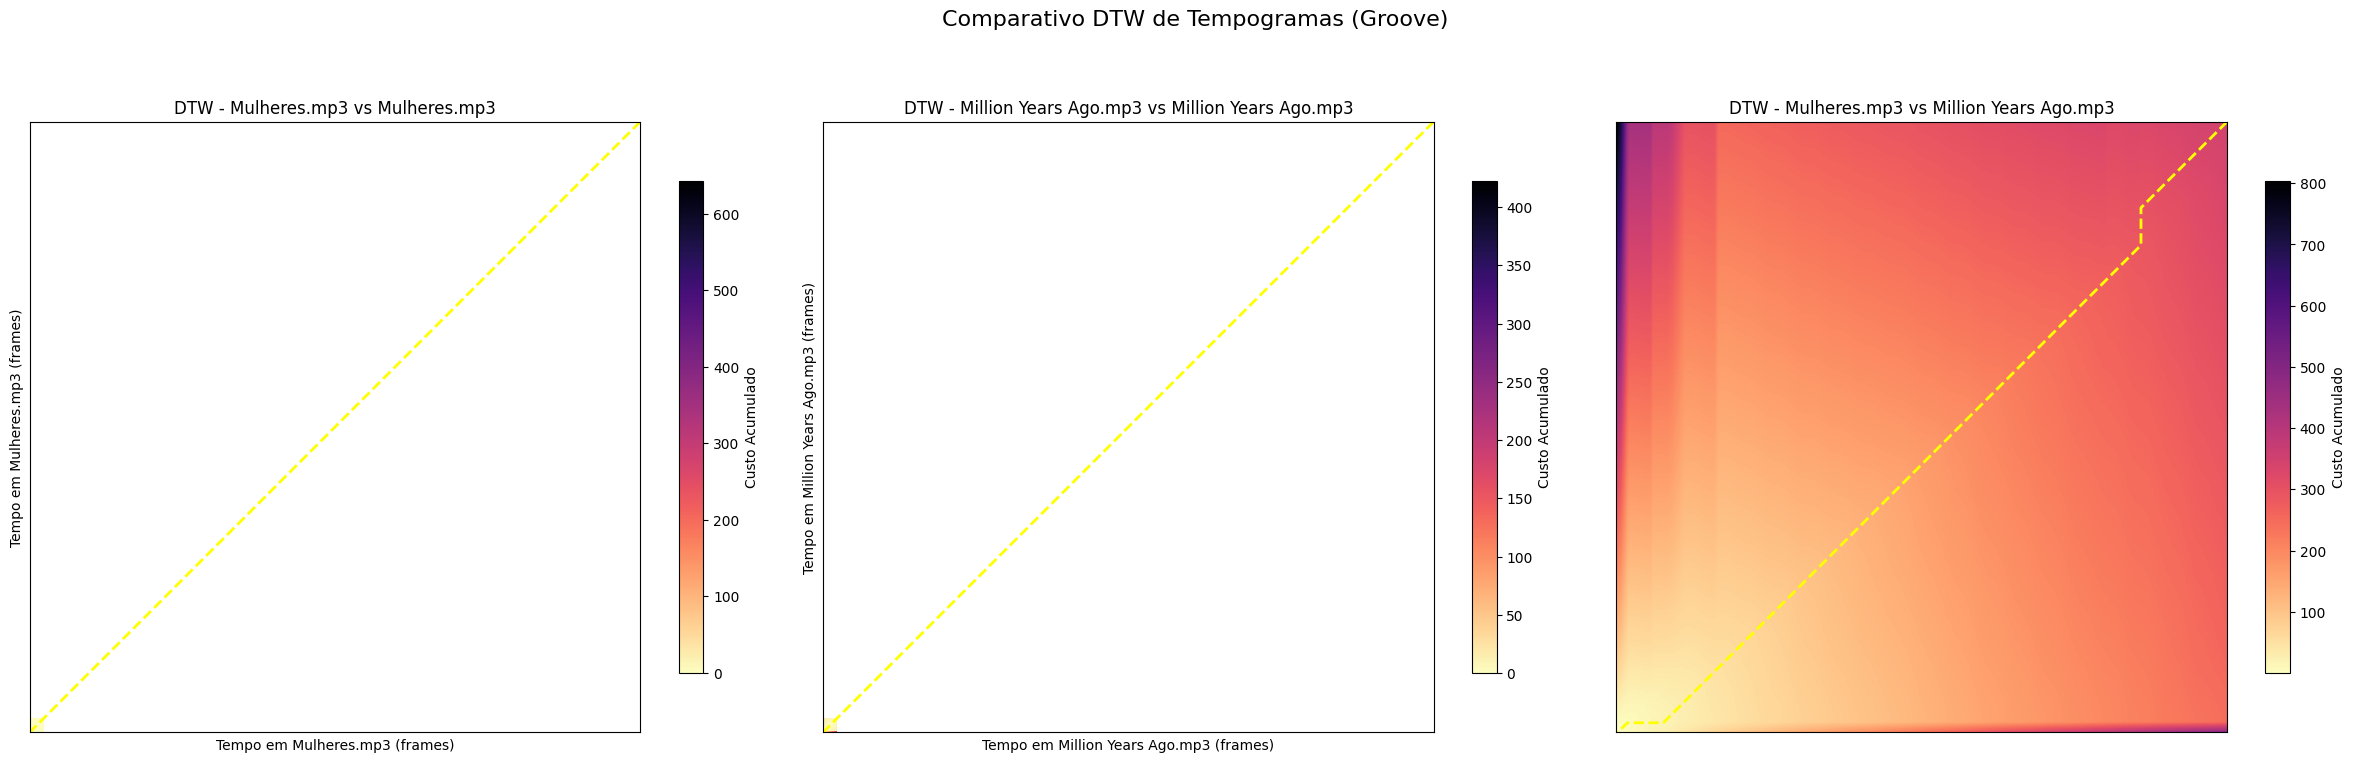

Distância DTW total (tempogramas entre músicas): 0.1575
Distância DTW média (tempogramas entre músicas): 0.0001


In [ ]:
plot_dtw_tempograms_comparativo(
    D_tempo_orig, wp_tempo_orig, f'DTW - {file_original} vs {file_original}', f'Tempo em {file_original} (frames)', f'Tempo em {file_original} (frames)',
    D_tempo_acus, wp_tempo_acus, f'DTW - {file_acusado} vs {file_acusado}', f'Tempo em {file_acusado} (frames)', f'Tempo em {file_acusado} (frames)',
    D_tempo_cross, wp_tempo_cross, f'DTW - {file_original} vs {file_acusado}', f'Tempo em {file_acusado} (frames)', f'Tempo em {file_original} (frames)',
    suptitle='Comparativo DTW de Tempogramas (Groove)'
)


dist_total = D_tempo_cross[wp_tempo_cross[-1, 0], wp_tempo_cross[-1, 1]]
dist_média = dist_total / len(wp_tempo_cross)
print(f'Distância DTW total (tempogramas entre músicas): {dist_total:.4f}')
print(f'Distância DTW média (tempogramas entre músicas): {dist_média:.4f}')